# 🚨 Fraud Detection — 1M Transactions · 7 Fraud Types

---

### Dataset Files
| File | Size | Description |
|---|---|---|
| `transactions.csv` | ~122 MB | **PRIMARY** — 1M transactions with `fraud_type` target |
| `account_profiles.csv` | ~6 MB | Account behavioral features |
| `fraud_patterns.csv` | ~0 MB | Per-fraud-type statistics |
| `network_edges.csv` | ~0.3 MB | Fraud ring graph edges |
| `time_series_stats.csv` | ~1.5 MB | Hourly fraud statistics |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, gc
from datetime import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print('✅ imbalanced-learn available')
except ImportError:
    SMOTE_AVAILABLE = False
    print("⚠️  imbalanced-learn not found — will use class_weight='balanced'")

from lightgbm import LGBMClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f'✅ Environment ready')
print(f'   NumPy    : {np.__version__}')
print(f'   Pandas   : {pd.__version__}')
print(f'   LightGBM : {lgb.__version__}')
print(f'   XGBoost  : {xgb.__version__}')

✅ imbalanced-learn available
✅ Environment ready
   NumPy    : 2.0.2
   Pandas   : 2.3.3
   LightGBM : 4.6.0
   XGBoost  : 3.2.0


## 📂 2. Data Discovery — All 5 Files

In [2]:
print('🔍 Scanning /kaggle/input ...\n')

all_files, csv_files = [], []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for fname in filenames:
        fpath = os.path.join(dirname, fname)
        all_files.append(fpath)
        if fname.endswith('.csv'):
            csv_files.append(fpath)
        try:
            sz = os.path.getsize(fpath)/1024/1024
            print(f'   📄 {fpath}  ({sz:.2f} MB)')
        except:
            print(f'   📄 {fpath}')

print(f'\n📊 Summary: {len(all_files)} total files | {len(csv_files)} CSV files')
if not csv_files:
    raise FileNotFoundError('❌ No CSV files found in /kaggle/input!')

def find_file(csv_list, keywords):
    for kw in keywords:
        for p in csv_list:
            if kw.lower() in os.path.basename(p).lower():
                return p
    return None

path_transactions = find_file(csv_files, ['transaction'])
path_accounts     = find_file(csv_files, ['account_profile', 'account'])
path_patterns     = find_file(csv_files, ['fraud_pattern', 'pattern'])
path_network      = find_file(csv_files, ['network_edge', 'network'])
path_timeseries   = find_file(csv_files, ['time_series', 'timeseries', 'ts_'])

routes = {
    'transactions'     : path_transactions,
    'account_profiles' : path_accounts,
    'fraud_patterns'   : path_patterns,
    'network_edges'    : path_network,
    'time_series_stats': path_timeseries,
}

print('\n🔗 File Routing:')
for name, path in routes.items():
    if path:
        sz = os.path.getsize(path)/1024/1024
        print(f'   ✅  {name:<20} → {os.path.basename(path)} ({sz:.2f} MB)')
    else:
        print(f'   ⚠️  {name:<20} → NOT FOUND')

if path_transactions is None:
    raise FileNotFoundError('❌ transactions.csv not found — cannot proceed!')

🔍 Scanning /kaggle/input ...

   📄 /kaggle/input/datasets/sergionefedov/fraud-detection-1m-transactions-7-fraud-types/network_edges.csv  (0.31 MB)
   📄 /kaggle/input/datasets/sergionefedov/fraud-detection-1m-transactions-7-fraud-types/fraud_patterns.csv  (0.00 MB)
   📄 /kaggle/input/datasets/sergionefedov/fraud-detection-1m-transactions-7-fraud-types/account_profiles.csv  (5.95 MB)
   📄 /kaggle/input/datasets/sergionefedov/fraud-detection-1m-transactions-7-fraud-types/time_series_stats.csv  (1.49 MB)
   📄 /kaggle/input/datasets/sergionefedov/fraud-detection-1m-transactions-7-fraud-types/transactions.csv  (122.23 MB)

📊 Summary: 5 total files | 5 CSV files

🔗 File Routing:
   ✅  transactions         → transactions.csv (122.23 MB)
   ✅  account_profiles     → account_profiles.csv (5.95 MB)
   ✅  fraud_patterns       → fraud_patterns.csv (0.00 MB)
   ✅  network_edges        → network_edges.csv (0.31 MB)
   ✅  time_series_stats    → time_series_stats.csv (1.49 MB)


## 🔄 3. Multi-File Data Loading

In [3]:
def safe_load(path, name, nrows=None):
    if path is None:
        print(f'   ⚠️  Skipping {name} — path not found')
        return None
    print(f'⏳ Loading {name}...')
    try:
        df = pd.read_csv(path, low_memory=False, nrows=nrows)
        print(f'   ✅ {name}: {df.shape[0]:,} rows × {df.shape[1]} cols  '
              f'({df.memory_usage(deep=True).sum()/1024/1024:.2f} MB)')
        return df
    except Exception as e:
        print(f'   ❌ Failed: {e}'); raise

df_txn = safe_load(path_transactions, 'transactions')
df_acc = safe_load(path_accounts,     'account_profiles')
df_pat = safe_load(path_patterns,     'fraud_patterns')
df_net = safe_load(path_network,      'network_edges')
df_ts  = safe_load(path_timeseries,   'time_series_stats')

print('\n📄 Transactions — columns:')
print(df_txn.columns.tolist())
print('\nFirst 3 rows:')
display(df_txn.head(3))
print('\n📄 Account Profiles — first 3 rows:')
if df_acc is not None: display(df_acc.head(3))
print('\n📄 Fraud Patterns:')
if df_pat is not None: display(df_pat)
print('\n📄 Network Edges — first 3 rows:')
if df_net is not None: display(df_net.head(3))
print('\n📄 Time Series Stats — first 3 rows:')
if df_ts is not None: display(df_ts.head(3))

⏳ Loading transactions...
   ✅ transactions: 1,000,000 rows × 23 cols  (492.63 MB)
⏳ Loading account_profiles...
   ✅ account_profiles: 50,000 rows × 23 cols  (15.59 MB)
⏳ Loading fraud_patterns...
   ✅ fraud_patterns: 7 rows × 12 cols  (0.00 MB)
⏳ Loading network_edges...
   ✅ network_edges: 7,411 rows × 6 cols  (1.69 MB)
⏳ Loading time_series_stats...
   ✅ time_series_stats: 26,280 rows × 10 cols  (3.51 MB)

📄 Transactions — columns:
['transaction_id', 'account_id', 'timestamp', 'hour_of_day', 'day_of_week', 'is_weekend', 'amount', 'merchant_category', 'mcc_code', 'merchant_country', 'card_present', 'device_type', 'device_known', 'ip_risk_score', 'is_foreign_txn', 'time_since_last_s', 'velocity_1h', 'amount_vs_avg_ratio', 'account_age_days', 'has_2fa', 'credit_limit', 'is_fraud', 'fraud_pattern']

First 3 rows:


,transaction_id,account_id,timestamp,hour_of_day,day_of_week,is_weekend,amount,merchant_category,mcc_code,merchant_country,card_present,device_type,device_known,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud,fraud_pattern
0,TXN000000001,ACC0016173,2023-02-21 08:02:38,8,1,0,168.4200,travel,4511,CA,0,mobile_app,1,53.2000,1,21,3,2.6423,3256,1,3958.4600,0,NaN
1,TXN000000002,ACC0011196,2024-05-12 23:13:34,23,6,1,85.7800,online_retail,5999,AU,0,web_browser,1,25.3000,1,234,1,0.7279,1527,1,3553.3500,0,NaN
2,TXN000000003,ACC0001181,2023-09-22 23:28:21,23,4,0,20.1500,pharmacy,5912,CA,0,web_browser,1,21.3000,1,85,1,0.1851,2230,1,4362.5700,0,NaN



📄 Account Profiles — first 3 rows:


,account_id,account_age_days,credit_limit,home_country,risk_score,is_high_risk,avg_txn_amount,avg_monthly_txns,has_2fa,account_type,total_transactions,total_amount,avg_amount,max_amount,fraud_count,fraud_amount,pct_foreign,avg_velocity,unique_countries,unique_categories,avg_ip_risk,fraud_rate,is_fraudster
0,ACC0000001,353,2171.4200,US,16.5000,0,90.8200,71.1000,1,personal,49.0000,7246.6000,147.8900,740.4600,0.0000,0.0000,0.3500,1.2700,9.0000,11.0000,22.9800,0.0000,0.0000
1,ACC0000002,2831,3031.3800,US,25.4000,0,63.7800,7.4000,1,business,2.0000,280.7900,140.3900,186.1300,1.0000,186.1300,0.5000,4.0000,2.0000,2.0000,52.4500,0.5000,1.0000
2,ACC0000003,2399,7533.7500,US,10.6000,0,72.1800,31.9000,0,personal,18.0000,4435.6900,246.4300,1175.8600,0.0000,0.0000,0.1700,1.4400,3.0000,8.0000,15.5000,0.0000,0.0000



📄 Fraud Patterns:


,fraud_pattern,description,transaction_count,fraud_share_pct,avg_amount,median_amount,pct_night_0_5,pct_foreign,pct_card_not_present,avg_velocity_1h,avg_ip_risk,pct_no_2fa
0,card_not_present,Online/CNP fraud — stolen card details used wi...,5982,34.8900,771.7800,268.6300,41.3200,58.0600,73.1200,3.9800,55.2600,42.2400
1,account_takeover,Fraudster gains access to legitimate account v...,3432,20.0200,1203.1300,436.7800,40.8800,59.6400,74.2400,3.9600,55.8900,41.7200
2,card_present_stolen,Physical card stolen and used at POS terminals,3120,18.2000,556.8400,200.2700,40.8300,57.2400,73.1700,3.9500,54.9900,40.6100
3,friendly_fraud,Legitimate cardholder disputes valid transacti...,1726,10.0700,352.6100,120.8000,38.9900,55.9700,74.6800,3.9300,54.9100,42.4700
4,atm_fraud,ATM skimming or card trapping to clone card,1216,7.0900,466.2600,164.5300,40.8700,60.4400,76.2300,4.0400,55.6000,39.3900
5,money_laundering,Series of transactions to disguise illicit fun...,1011,5.9000,93.5900,35.4200,40.3600,60.6300,72.2100,3.9700,55.7900,44.0200
6,identity_theft,New account opened using stolen personal infor...,656,3.8300,1163.5000,387.2600,38.7200,57.6200,75.3000,3.9300,55.1400,42.2300



📄 Network Edges — first 3 rows:


,account_a,account_b,shared_type,connection_count,ring_id,both_fraud
0,ACC0017803,ACC0040032,phone,7,RING0001,1
1,ACC0017803,ACC0042246,email_domain,12,RING0001,1
2,ACC0017803,ACC0029491,phone,13,RING0001,1



📄 Time Series Stats — first 3 rows:


,hour,transaction_count,fraud_count,total_amount,avg_amount,avg_ip_risk,fraud_rate,hour_of_day,day_of_week,is_weekend
0,2022-01-01 00:00:00,40,1,9341.6600,233.5400,19.9200,0.0250,0,5,1
1,2022-01-01 01:00:00,43,0,6295.7700,146.4100,20.3200,0.0000,1,5,1
2,2022-01-01 02:00:00,41,1,10763.9500,262.5400,22.1300,0.0244,2,5,1


## 📊 4. Data Quality Audit

In [4]:
def quality_audit(df, name):
    if df is None: print(f'⚠️  {name}: skipped (not loaded)'); return
    print('\n' + '='*70)
    print(f'📊 QUALITY AUDIT: {name}')
    print('='*70)
    print(f'  Shape  : {df.shape[0]:,} rows × {df.shape[1]} cols')
    print(f'  Memory : {df.memory_usage(deep=True).sum()/1024/1024:.2f} MB')
    print(f'  Dtypes : {dict(df.dtypes.value_counts())}')
    miss = df.isnull().sum()
    total_miss = miss.sum()
    print(f'  Missing: {total_miss:,} across {(miss>0).sum()} columns')
    if total_miss > 0:
        display(pd.DataFrame({'Col':miss.index,'Missing':miss.values,
                               'Pct%':100*miss.values/len(df)}).query('Missing>0'))
    print(f'  Dups   : {df.duplicated().sum():,}')
    if df.select_dtypes(include='object').columns.tolist():
        print(f'  Cat cols: {df.select_dtypes(include="object").columns.tolist()}')
    print('='*70)

quality_audit(df_txn, 'transactions')
quality_audit(df_acc, 'account_profiles')
quality_audit(df_pat, 'fraud_patterns')
quality_audit(df_net, 'network_edges')
quality_audit(df_ts,  'time_series_stats')


📊 QUALITY AUDIT: transactions
  Shape  : 1,000,000 rows × 23 cols
  Memory : 492.63 MB
  Dtypes : {dtype('int64'): np.int64(12), dtype('O'): np.int64(7), dtype('float64'): np.int64(4)}
  Missing: 982,857 across 1 columns


,Col,Missing,Pct%
22,fraud_pattern,982857,98.2857


  Dups   : 0
  Cat cols: ['transaction_id', 'account_id', 'timestamp', 'merchant_category', 'merchant_country', 'device_type', 'fraud_pattern']

📊 QUALITY AUDIT: account_profiles
  Shape  : 50,000 rows × 23 cols
  Memory : 15.59 MB
  Dtypes : {dtype('float64'): np.int64(17), dtype('O'): np.int64(3), dtype('int64'): np.int64(3)}
  Missing: 0 across 0 columns
  Dups   : 0
  Cat cols: ['account_id', 'home_country', 'account_type']

📊 QUALITY AUDIT: fraud_patterns
  Shape  : 7 rows × 12 cols
  Memory : 0.00 MB
  Dtypes : {dtype('float64'): np.int64(9), dtype('O'): np.int64(2), dtype('int64'): np.int64(1)}
  Missing: 0 across 0 columns
  Dups   : 0
  Cat cols: ['fraud_pattern', 'description']

📊 QUALITY AUDIT: network_edges
  Shape  : 7,411 rows × 6 cols
  Memory : 1.69 MB
  Dtypes : {dtype('O'): np.int64(4), dtype('int64'): np.int64(2)}
  Missing: 3,000 across 1 columns


,Col,Missing,Pct%
4,ring_id,3000,40.4804


  Dups   : 0
  Cat cols: ['account_a', 'account_b', 'shared_type', 'ring_id']

📊 QUALITY AUDIT: time_series_stats
  Shape  : 26,280 rows × 10 cols
  Memory : 3.51 MB
  Dtypes : {dtype('int64'): np.int64(5), dtype('float64'): np.int64(4), dtype('O'): np.int64(1)}
  Missing: 0 across 0 columns
  Dups   : 0
  Cat cols: ['hour']


## 🎯 5. Target Variable Detection

✅ Target column detected: 'is_fraud'

Value counts:
is_fraud
0    982857
1     17143
Name: count, dtype: int64

Unique values: 2

🔢 Classification type: BINARY


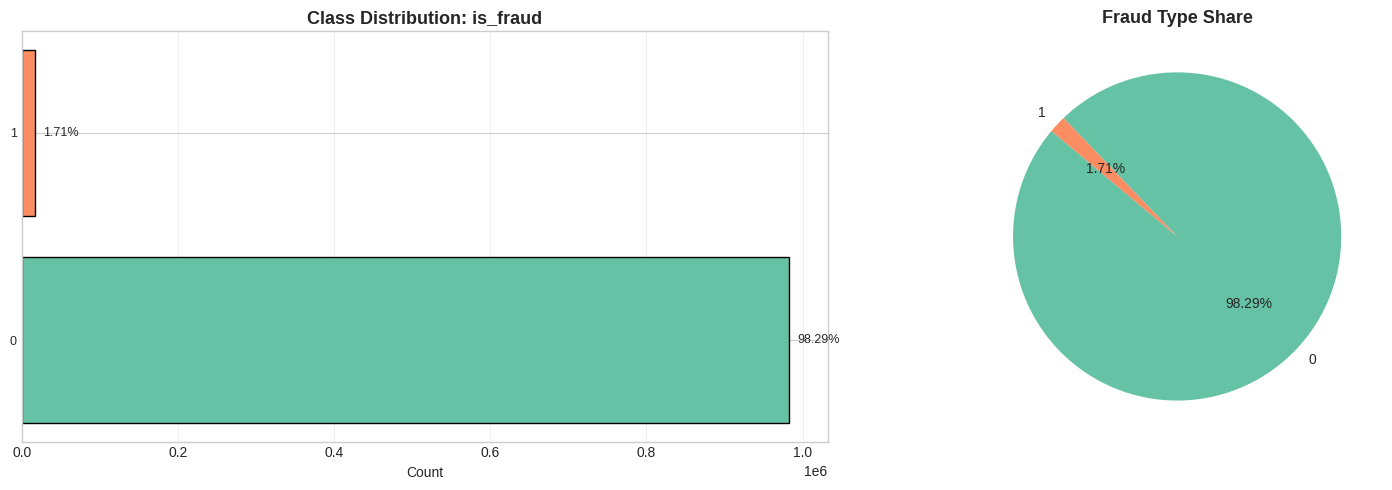

✅ Target analysis complete


In [5]:
TARGET = None
for candidate in ['fraud_type','is_fraud','fraud','label','fraud_label','target']:
    if candidate in df_txn.columns:
        TARGET = candidate
        break

if TARGET is None:
    fraud_cols = [c for c in df_txn.columns if 'fraud' in c.lower()]
    if fraud_cols:
        TARGET = fraud_cols[0]

if TARGET is None:
    raise ValueError(f'❌ No fraud target found! Columns: {df_txn.columns.tolist()}')

print(f"✅ Target column detected: '{TARGET}'")
print(f'\nValue counts:')
print(df_txn[TARGET].value_counts())
print(f'\nUnique values: {df_txn[TARGET].nunique()}')

n_classes = df_txn[TARGET].nunique()
is_multiclass = n_classes > 2
print(f'\n🔢 Classification type: {"MULTI-CLASS (" + str(n_classes) + " classes)" if is_multiclass else "BINARY"}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
vc = df_txn[TARGET].value_counts()
colors = sns.color_palette('Set2', len(vc))
axes[0].barh(range(len(vc)), vc.values, color=colors, edgecolor='black')
axes[0].set_yticks(range(len(vc)))
axes[0].set_yticklabels(vc.index.astype(str), fontsize=9)
axes[0].set_title(f'Class Distribution: {TARGET}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count'); axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(vc.values):
    axes[0].text(v + max(vc)*0.01, i, f'{100*v/len(df_txn):.2f}%', va='center', fontsize=9)

axes[1].pie(vc.values, labels=vc.index.astype(str), autopct='%1.2f%%',
            colors=colors, startangle=140)
axes[1].set_title('Fraud Type Share', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('✅ Target analysis complete')

## 🧹 6. Data Cleaning — Zero-NaN Pipeline

In [6]:
def clean_df(df, name, drop_thresh=0.5):
    if df is None: return None
    print(f'\n{"="*60}')
    print(f'🧹 Cleaning: {name}  |  Start: {df.shape}')
    dc = df.copy()
    miss_frac = dc.isnull().mean()
    high_miss = miss_frac[miss_frac > drop_thresh].index.tolist()
    if high_miss:
        dc.drop(columns=high_miss, inplace=True)
        print(f'  ✅ Dropped {len(high_miss)} cols >50% missing')
    for col in dc.select_dtypes(include=[np.number]).columns:
        n = dc[col].isnull().sum()
        if n > 0:
            dc[col].fillna(dc[col].median(), inplace=True)
            print(f'  ✅ {col}: {n} NaN → median')
    for col in dc.select_dtypes(include=['object','category']).columns:
        n = dc[col].isnull().sum()
        if n > 0:
            mode = dc[col].mode()
            fill = mode[0] if len(mode)>0 else 'Unknown'
            dc[col].fillna(fill, inplace=True)
            print(f"  ✅ {col}: {n} NaN → '{fill}'")
    dup = dc.duplicated().sum()
    if dup > 0:
        dc.drop_duplicates(inplace=True)
        print(f'  ✅ Removed {dup} duplicates')
    dc.reset_index(drop=True, inplace=True)
    assert dc.isnull().sum().sum() == 0, f'❌ NaN remain in {name}!'
    print(f'  ✅ PASS: 0 NaN | Final: {dc.shape}')
    return dc

df_txn_c = clean_df(df_txn, 'transactions')
df_acc_c = clean_df(df_acc, 'account_profiles')
df_pat_c = clean_df(df_pat, 'fraud_patterns')
df_net_c = clean_df(df_net, 'network_edges')
df_ts_c  = clean_df(df_ts,  'time_series_stats')

print('\n' + '='*60)
print('✅ ALL DATASETS CLEANED — ZERO NaN GUARANTEED')
print('='*60)


🧹 Cleaning: transactions  |  Start: (1000000, 23)
  ✅ Dropped 1 cols >50% missing
  ✅ PASS: 0 NaN | Final: (1000000, 22)

🧹 Cleaning: account_profiles  |  Start: (50000, 23)
  ✅ PASS: 0 NaN | Final: (50000, 23)

🧹 Cleaning: fraud_patterns  |  Start: (7, 12)
  ✅ PASS: 0 NaN | Final: (7, 12)

🧹 Cleaning: network_edges  |  Start: (7411, 6)
  ✅ ring_id: 3000 NaN → 'RING0040'
  ✅ PASS: 0 NaN | Final: (7411, 6)

🧹 Cleaning: time_series_stats  |  Start: (26280, 10)
  ✅ PASS: 0 NaN | Final: (26280, 10)

✅ ALL DATASETS CLEANED — ZERO NaN GUARANTEED


## 📈 7. Exploratory Data Analysis

In [7]:
print(f'📊 EDA on transactions.csv  |  {df_txn_c.shape[0]:,} rows × {df_txn_c.shape[1]} cols')
num_cols_txn = df_txn_c.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_txn = df_txn_c.select_dtypes(include='object').columns.tolist()
print(f'   Numeric: {len(num_cols_txn)} | Categorical: {len(cat_cols_txn)}')
display(df_txn_c.describe())

📊 EDA on transactions.csv  |  1,000,000 rows × 22 cols
   Numeric: 16 | Categorical: 6


,hour_of_day,day_of_week,is_weekend,amount,mcc_code,card_present,device_known,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud
count,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000
mean,11.4942,3.0033,0.2872,183.7383,5703.7133,0.3507,0.8923,21.6058,0.2944,180.1126,1.0504,3.2985,1833.5889,0.6476,6706.9382,0.0171
std,6.9210,2.0027,0.4524,316.6939,548.9180,0.4772,0.3100,16.2697,0.4558,180.1486,1.0951,7.1571,1046.4899,0.4777,6174.1641,0.1298
min,0.0000,0.0000,0.0000,1.8300,4511.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0118,30.0000,0.0000,500.0000,0.0000
25%,5.0000,1.0000,0.0000,43.4800,5411.0000,0.0000,1.0000,8.5000,0.0000,52.0000,0.0000,0.5971,926.0000,0.0000,2833.7500,0.0000
50%,11.0000,3.0000,0.0000,81.1400,5734.0000,0.0000,1.0000,18.7000,0.0000,125.0000,1.0000,1.2853,1832.0000,1.0000,4880.1000,0.0000
75%,17.0000,5.0000,1.0000,189.7600,5999.0000,1.0000,1.0000,30.7000,1.0000,250.0000,2.0000,3.1555,2738.0000,1.0000,8384.0400,0.0000
max,23.0000,6.0000,1.0000,25000.0000,7995.0000,1.0000,1.0000,100.0000,1.0000,2733.0000,15.0000,945.5371,3649.0000,1.0000,50000.0000,1.0000


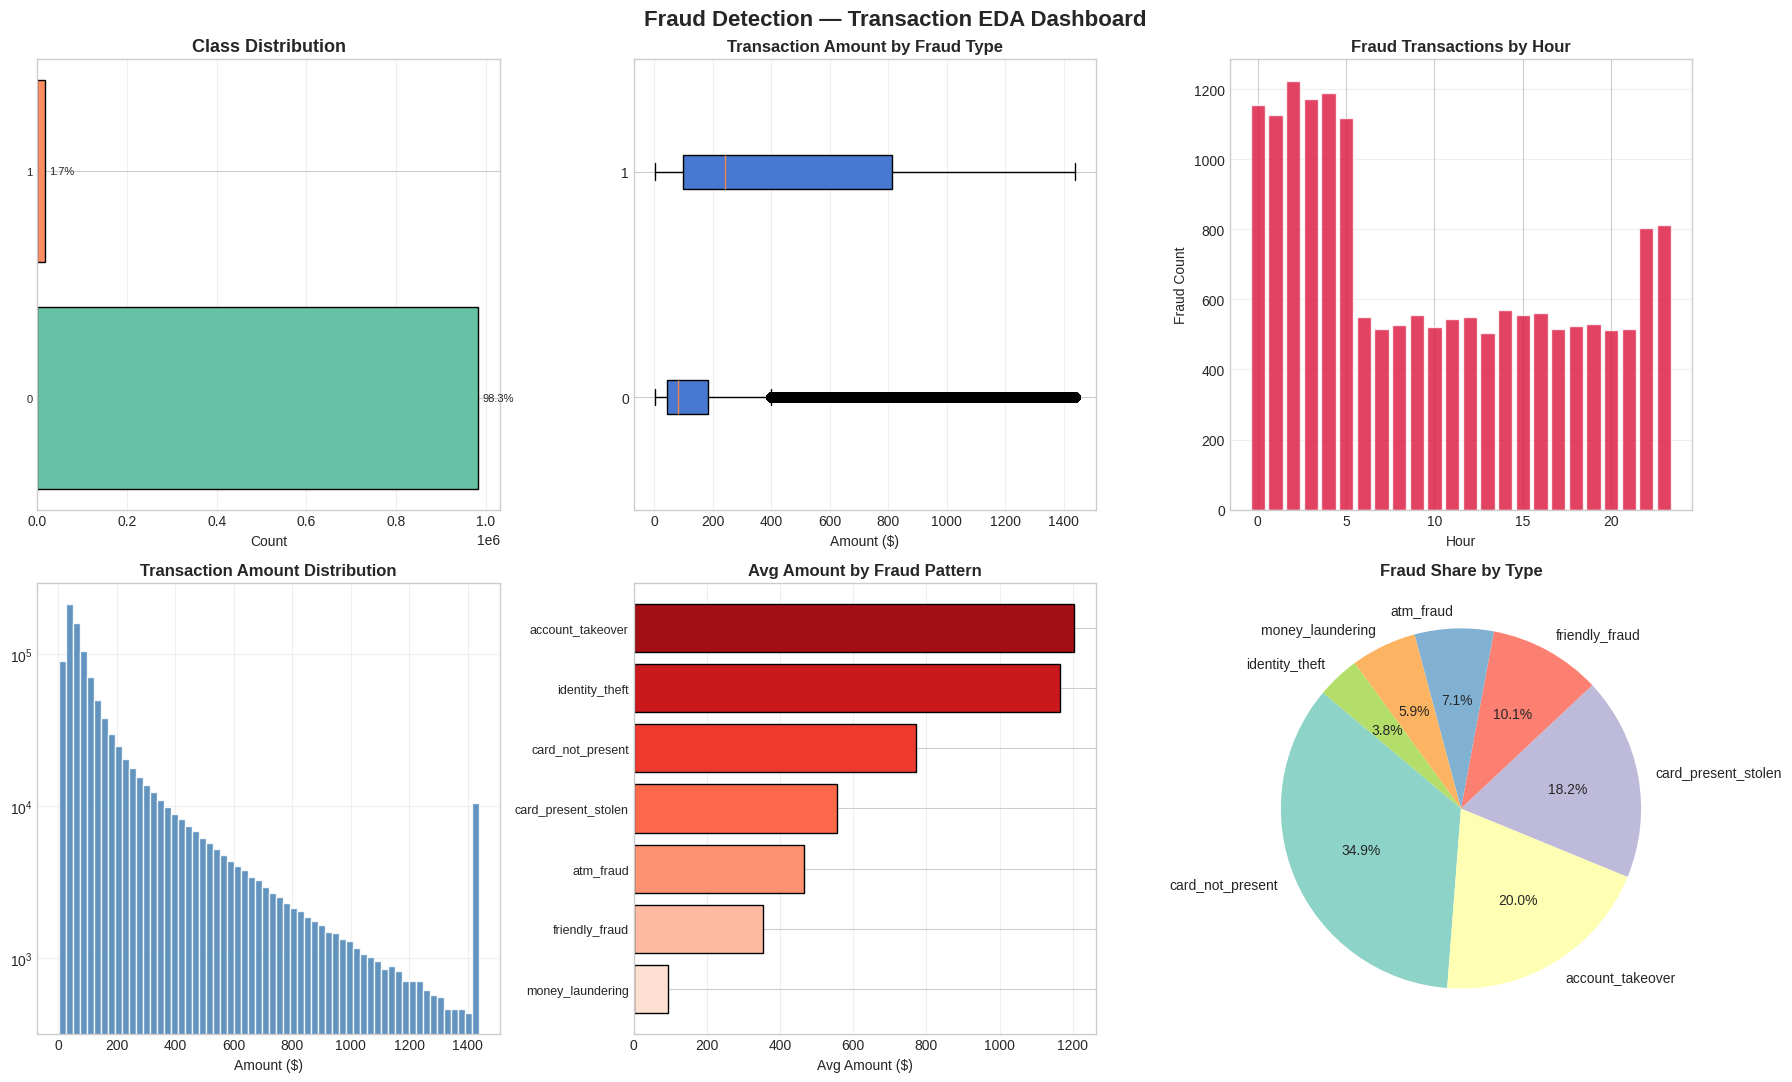

✅ EDA Dashboard rendered


In [8]:
amt_col = next((c for c in ['amount','transaction_amount','amt','value'] if c in df_txn_c.columns), None)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Fraud Detection — Transaction EDA Dashboard', fontsize=16, fontweight='bold')

vc = df_txn_c[TARGET].value_counts()
colors = sns.color_palette('Set2', len(vc))
axes[0,0].barh(range(len(vc)), vc.values, color=colors, edgecolor='black')
axes[0,0].set_yticks(range(len(vc)))
axes[0,0].set_yticklabels(vc.index.astype(str), fontsize=8)
axes[0,0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Count'); axes[0,0].grid(axis='x', alpha=0.3)
for i, v in enumerate(vc.values):
    axes[0,0].text(v+max(vc)*0.01, i, f'{100*v/len(df_txn_c):.1f}%', va='center', fontsize=8)

if amt_col:
    fraud_amounts = [df_txn_c[df_txn_c[TARGET]==cls][amt_col].clip(upper=df_txn_c[amt_col].quantile(0.99))
                     for cls in vc.index]
    axes[0,1].boxplot(fraud_amounts, labels=[str(x)[:15] for x in vc.index],
                      patch_artist=True, vert=False)
    axes[0,1].set_title('Transaction Amount by Fraud Type', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('Amount ($)'); axes[0,1].grid(axis='x', alpha=0.3)
else:
    axes[0,1].text(0.5,0.5,'amount column not found',ha='center',va='center')

hour_col = next((c for c in ['hour','hour_of_day','transaction_hour'] if c in df_txn_c.columns), None)
if hour_col:
    hourly_fraud = df_txn_c[df_txn_c[TARGET] != 'legitimate'].groupby(hour_col).size() if df_txn_c[TARGET].dtype=='object' else df_txn_c[df_txn_c[TARGET]!=0].groupby(hour_col).size()
    axes[0,2].bar(hourly_fraud.index, hourly_fraud.values, color='crimson', alpha=0.8, edgecolor='white')
    axes[0,2].set_title('Fraud Transactions by Hour', fontsize=12, fontweight='bold')
    axes[0,2].set_xlabel('Hour'); axes[0,2].set_ylabel('Fraud Count'); axes[0,2].grid(axis='y', alpha=0.3)
else:
    axes[0,2].text(0.5,0.5,'hour column not found',ha='center',va='center')

if amt_col:
    axes[1,0].hist(df_txn_c[amt_col].clip(upper=df_txn_c[amt_col].quantile(0.99)),
                   bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[1,0].set_title('Transaction Amount Distribution', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('Amount ($)'); axes[1,0].set_yscale('log'); axes[1,0].grid(alpha=0.3)

if df_pat_c is not None and 'avg_amount' in df_pat_c.columns:
    pat_col = 'fraud_pattern' if 'fraud_pattern' in df_pat_c.columns else df_pat_c.columns[0]
    df_ps = df_pat_c.sort_values('avg_amount', ascending=True)
    axes[1,1].barh(range(len(df_ps)), df_ps['avg_amount'],
                   color=sns.color_palette('Reds', len(df_ps)), edgecolor='black')
    axes[1,1].set_yticks(range(len(df_ps)))
    axes[1,1].set_yticklabels(df_ps[pat_col], fontsize=9)
    axes[1,1].set_title('Avg Amount by Fraud Pattern', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Avg Amount ($)'); axes[1,1].grid(axis='x', alpha=0.3)
else:
    axes[1,1].text(0.5,0.5,'fraud_patterns not available',ha='center',va='center')

if df_pat_c is not None and 'fraud_share_pct' in df_pat_c.columns:
    pat_col = 'fraud_pattern' if 'fraud_pattern' in df_pat_c.columns else df_pat_c.columns[0]
    df_ps2 = df_pat_c.sort_values('fraud_share_pct', ascending=False)
    axes[1,2].pie(df_ps2['fraud_share_pct'], labels=df_ps2[pat_col],
                  autopct='%1.1f%%', colors=sns.color_palette('Set3', len(df_ps2)), startangle=140)
    axes[1,2].set_title('Fraud Share by Type', fontsize=12, fontweight='bold')
else:
    axes[1,2].text(0.5,0.5,'fraud_share_pct not available',ha='center',va='center')

plt.tight_layout(); plt.show()
print('✅ EDA Dashboard rendered')

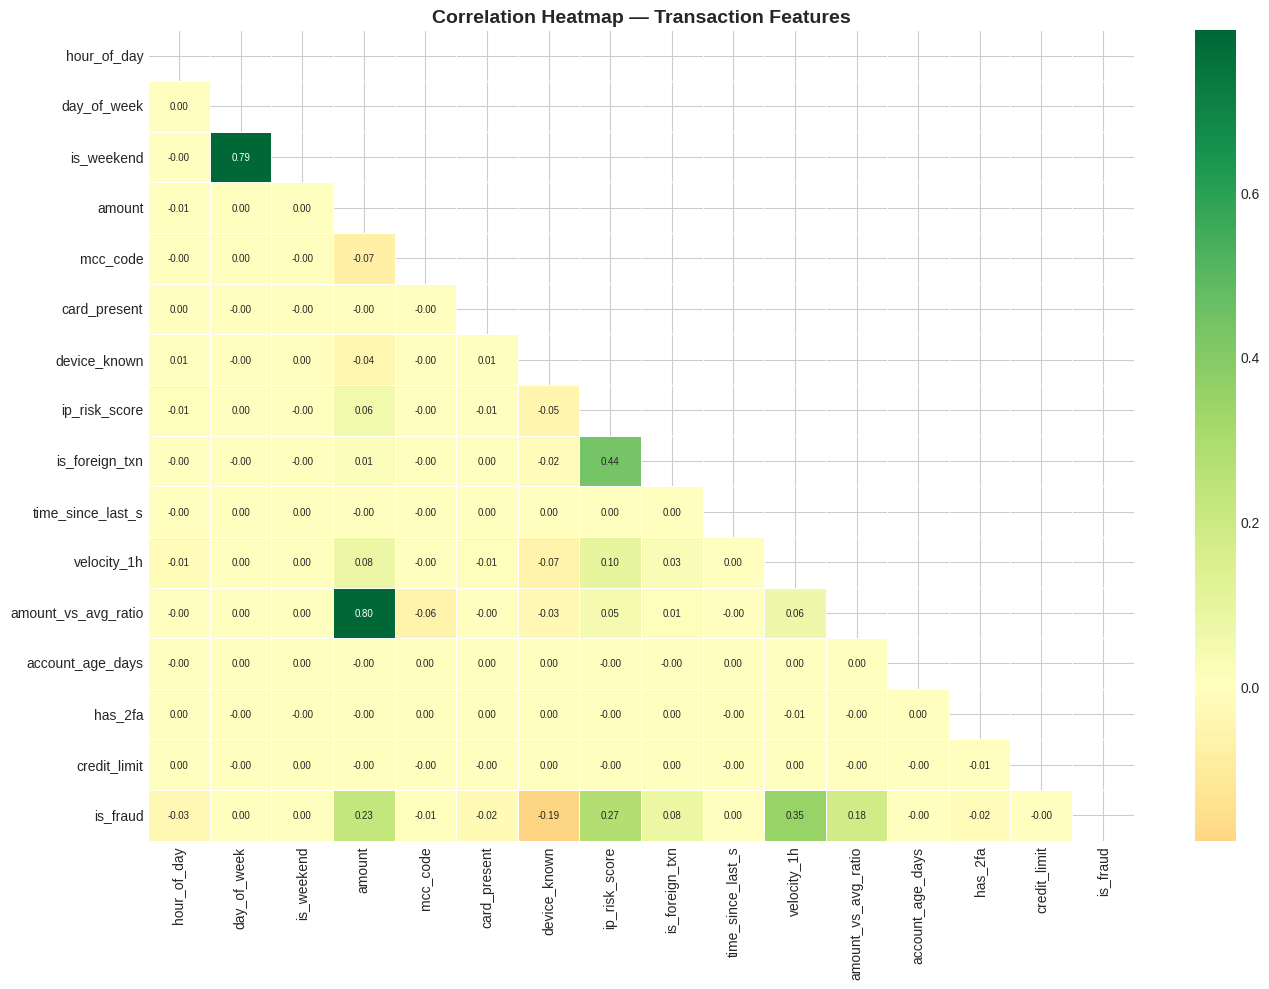

✅ Correlation heatmap rendered


In [9]:
num_feats = df_txn_c.select_dtypes(include=[np.number]).columns.tolist()
if len(num_feats) >= 2:
    corr = df_txn_c[num_feats].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, linewidths=0.5, ax=ax, annot_kws={'size':7})
    ax.set_title('Correlation Heatmap — Transaction Features', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    print('✅ Correlation heatmap rendered')
else:
    print('⚠️  Not enough numeric columns for heatmap')

## ⚙️ 8. Feature Engineering

In [10]:
def safe_divide(num, denom, fill=0):
    return (num / (denom.replace(0, np.nan) + 1e-10)).replace([np.inf,-np.inf], fill).fillna(fill)

def safe_log(s, fill=0):
    return pd.Series(np.log1p(np.maximum(s, 0)), index=s.index).replace([np.inf,-np.inf], fill).fillna(fill)

df_feat = df_txn_c.copy()
print(f'Starting shape: {df_feat.shape}')

amt_col = next((c for c in ['amount','transaction_amount','amt'] if c in df_feat.columns), None)
if amt_col:
    df_feat['log_amount']        = safe_log(df_feat[amt_col])
    df_feat['is_round_amount']   = ((df_feat[amt_col] % 10 == 0) & (df_feat[amt_col] > 0)).astype(int)
    df_feat['high_amount_flag']  = (df_feat[amt_col] > df_feat[amt_col].quantile(0.95)).astype(int)
    df_feat['low_amount_flag']   = (df_feat[amt_col] < df_feat[amt_col].quantile(0.05)).astype(int)
    print('  ✅ Amount features added')

dt_col = next((c for c in ['timestamp','datetime','date','transaction_date','created_at'] if c in df_feat.columns), None)
if dt_col:
    try:
        df_feat[dt_col] = pd.to_datetime(df_feat[dt_col], errors='coerce')
        df_feat['hour_of_day']  = df_feat[dt_col].dt.hour
        df_feat['day_of_week']  = df_feat[dt_col].dt.dayofweek
        df_feat['is_weekend']   = (df_feat['day_of_week'] >= 5).astype(int)
        df_feat['is_night']     = df_feat['hour_of_day'].between(0, 5).astype(int)
        df_feat['month']        = df_feat[dt_col].dt.month
        df_feat.drop(columns=[dt_col], inplace=True)
        print(f"  ✅ Temporal features from '{dt_col}'")
    except Exception as e:
        print(f'  ⚠️  Datetime parsing failed: {e}')

if df_net_c is not None:
    acc_col_net = next((c for c in ['account_id','account_a','src','source'] if c in df_net_c.columns), None)
    acc_col_txn = next((c for c in ['account_id','customer_id','user_id'] if c in df_feat.columns), None)
    if acc_col_net and acc_col_txn:
        b_col = 'account_b' if 'account_b' in df_net_c.columns else df_net_c.columns[1]
        c_col = 'connection_count' if 'connection_count' in df_net_c.columns else df_net_c.columns[2]
        net_agg = df_net_c.groupby(acc_col_net).agg(
            net_degree=(b_col, 'nunique'),
            net_strength=(c_col, 'sum')
        ).reset_index().rename(columns={acc_col_net: acc_col_txn})
        df_feat = df_feat.merge(net_agg, on=acc_col_txn, how='left')
        df_feat[['net_degree','net_strength']] = df_feat[['net_degree','net_strength']].fillna(0)
        df_feat['in_fraud_ring'] = (df_feat['net_degree'] > 0).astype(int)
        print('  ✅ Network features merged')
    else:
        print('  ⚠️  Cannot join network — account column mismatch')

if df_acc_c is not None:
    acc_id_col = next((c for c in ['account_id','customer_id','user_id'] if c in df_acc_c.columns), None)
    txn_id_col = next((c for c in ['account_id','customer_id','user_id'] if c in df_feat.columns), None)
    if acc_id_col and txn_id_col:
        merge_cols = [acc_id_col] + [c for c in df_acc_c.columns if c != acc_id_col and c not in df_feat.columns and c != TARGET]
        df_feat = df_feat.merge(df_acc_c[merge_cols].rename(columns={acc_id_col:txn_id_col}), on=txn_id_col, how='left')
        for c in df_feat.select_dtypes(include=[np.number]).columns:
            if df_feat[c].isnull().any(): df_feat[c].fillna(df_feat[c].median(), inplace=True)
        print(f'  ✅ Account profile features merged → shape: {df_feat.shape}')
    else:
        print('  ⚠️  Cannot join accounts — id column mismatch')

if 'risk_score' in df_feat.columns:
    df_feat['high_risk_flag']  = (df_feat['risk_score'] > df_feat['risk_score'].quantile(0.80)).astype(int)
    df_feat['log_risk_score']  = safe_log(df_feat['risk_score'])

if 'fraud_rate' in df_feat.columns:
    df_feat['log_fraud_rate']  = safe_log(df_feat['fraud_rate'] * 1000)
    df_feat['high_fraud_rate'] = (df_feat['fraud_rate'] > df_feat['fraud_rate'].quantile(0.75)).astype(int)

if 'avg_ip_risk' in df_feat.columns:
    df_feat['log_ip_risk']  = safe_log(df_feat['avg_ip_risk'])
    df_feat['high_ip_flag'] = (df_feat['avg_ip_risk'] > df_feat['avg_ip_risk'].quantile(0.80)).astype(int)

if 'credit_limit' in df_feat.columns and amt_col:
    df_feat['utilization'] = safe_divide(df_feat[amt_col], df_feat['credit_limit'])

for col in df_feat.select_dtypes(include=['object','category']).columns:
    if col == TARGET: continue
    le = LabelEncoder()
    df_feat[col] = le.fit_transform(df_feat[col].astype(str))
    print(f"  ✅ Encoded '{col}' ({df_feat[col].nunique()} cats)")

df_feat.replace([np.inf,-np.inf], np.nan, inplace=True)
for col in df_feat.select_dtypes(include=[np.number]).columns:
    if df_feat[col].isnull().any(): df_feat[col].fillna(df_feat[col].median(), inplace=True)

assert df_feat.isnull().sum().sum() == 0, '❌ NaN remain after FE!'
assert np.isinf(df_feat.select_dtypes(include=[np.number])).sum().sum() == 0

print(f'\n✅ Feature Engineering complete')
print(f'   Original txn cols : {df_txn_c.shape[1]} → Engineered: {df_feat.shape[1]} features')
print(f'   Samples: {df_feat.shape[0]:,}')

Starting shape: (1000000, 22)
  ✅ Amount features added
  ✅ Temporal features from 'timestamp'
  ✅ Network features merged
  ✅ Account profile features merged → shape: (1000000, 49)
  ✅ Encoded 'transaction_id' (1000000 cats)
  ✅ Encoded 'account_id' (49903 cats)
  ✅ Encoded 'merchant_category' (14 cats)
  ✅ Encoded 'merchant_country' (11 cats)
  ✅ Encoded 'device_type' (5 cats)
  ✅ Encoded 'home_country' (1 cats)
  ✅ Encoded 'account_type' (3 cats)

✅ Feature Engineering complete
   Original txn cols : 22 → Engineered: 56 features
   Samples: 1,000,000


## 🎯 9. Target Encoding & Train-Test Split

In [11]:
y_raw = df_feat[TARGET].copy()
feature_cols = [c for c in df_feat.select_dtypes(include=[np.number]).columns if c != TARGET]
X = df_feat[feature_cols].copy()

if y_raw.dtype == 'object':
    le_target = LabelEncoder()
    y = pd.Series(le_target.fit_transform(y_raw), name=TARGET)
    print('✅ Target label-encoded (multi-class)')
    print('   Mapping:')
    for i, cls in enumerate(le_target.classes_):
        print(f'     {i} → {cls}  ({(y==i).sum():,} samples)')
else:
    y = y_raw.astype(int).reset_index(drop=True)
    le_target = None
    print('✅ Target is numeric')
    print(y.value_counts())

X.reset_index(drop=True, inplace=True)
y.reset_index(drop=True, inplace=True)
assert X.isnull().sum().sum() == 0
assert y.isnull().sum() == 0
assert len(X) == len(y)

n_classes = y.nunique()
print(f'\n✅ X: {X.shape} | y: {y.shape}')
print(f'   Classes: {n_classes} | {"Multi-class" if n_classes>2 else "Binary"}')

✅ Target is numeric
is_fraud
0    982857
1     17143
Name: count, dtype: int64

✅ X: (1000000, 55) | y: (1000000,)
   Classes: 2 | Binary


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'✅ Stratified Split:')
print(f'   Train : {len(X_train):,} | Test: {len(X_test):,}')
print(f'   Train class dist: {dict(y_train.value_counts().head(8))}')

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

if SMOTE_AVAILABLE and y_train.nunique() == 2:
    try:
        sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
        X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
        X_train_sc_res, _ = sm.fit_resample(X_train_sc, y_train)
        print(f'\n✅ SMOTE: {len(X_train):,} → {len(X_train_res):,} samples')
    except Exception as e:
        print(f'⚠️  SMOTE failed ({e}) — using original')
        X_train_res, y_train_res = X_train, y_train
        X_train_sc_res = X_train_sc
else:
    if y_train.nunique() > 2:
        print('ℹ️  Multi-class — using class_weight="balanced"')
    X_train_res, y_train_res = X_train, y_train
    X_train_sc_res = X_train_sc

✅ Stratified Split:
   Train : 800,000 | Test: 200,000
   Train class dist: {0: np.int64(786286), 1: np.int64(13714)}

✅ SMOTE: 800,000 → 1,572,572 samples


## 🤖 10. Model Training

In [13]:
def evaluate_clf(model, X_tr, X_te, y_tr, y_te, model_name, cv=3):
    print(f'\n{"="*65}')
    print(f'🔍 {model_name}')
    print(f'{"="*65}')
    try:
        print('   ⏳ Training...')
        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_te)
        y_proba = None
        n_cls   = y_te.nunique()
        multi   = n_cls > 2
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_te)
        acc  = accuracy_score(y_te, y_pred)
        f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
        prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
        rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
        if y_proba is not None:
            roc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='weighted') if multi else roc_auc_score(y_te, y_proba[:,1])
        else:
            roc = None
        print(f'   Accuracy     : {acc:.4f}')
        print(f'   F1 (weighted): {f1:.4f}')
        print(f'   Precision    : {prec:.4f}')
        print(f'   Recall       : {rec:.4f}')
        if roc: print(f'   ROC-AUC      : {roc:.4f}')
        print(f'\n   Classification Report:')
        target_names = [str(c) for c in sorted(y_te.unique())]
        print(classification_report(y_te, y_pred, target_names=target_names, zero_division=0))
        try:
            cv_s = cross_val_score(model, X_tr, y_tr,
                                   cv=StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE),
                                   scoring='f1_weighted', n_jobs=-1)
            print(f'   {cv}-Fold CV F1: {cv_s.mean():.4f} ± {cv_s.std():.4f}')
        except Exception as cve:
            print(f'   ⚠️  CV failed: {cve}')
            cv_s = None
        return {'name':model_name,'model':model,'y_pred':y_pred,'y_proba':y_proba,
                'acc':acc,'f1':f1,'prec':prec,'rec':rec,'roc':roc,
                'cv_mean':cv_s.mean() if cv_s is not None else None}
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f'❌ ERROR: {e}'); return None

print('✅ evaluate_clf() defined')

✅ evaluate_clf() defined


In [14]:
n_cls    = y_train.nunique()
multi    = n_cls > 2
scale_pw = float((y_train_res==0).sum()) / max((y_train_res==1).sum(),1) if not multi else 1
results  = []

MAX_TRAIN = 100_000
if len(X_train_res) > MAX_TRAIN:
    from sklearn.utils import resample
    X_tr_fast, y_tr_fast = resample(
        X_train_res, y_train_res,
        n_samples=MAX_TRAIN, stratify=y_train_res, random_state=RANDOM_STATE
    )
    X_tr_sc_fast, _ = resample(
        X_train_sc_res, y_train_res,
        n_samples=MAX_TRAIN, stratify=y_train_res, random_state=RANDOM_STATE
    )
    print(f"⚡ Fast-train sample: {len(X_tr_fast):,} rows (from {len(X_train_res):,})")
else:
    X_tr_fast, y_tr_fast, X_tr_sc_fast = X_train_res, y_train_res, X_train_sc_res

# ── Updated evaluate_clf: accepts pre-fitted models ───────────────────
def evaluate_clf(model, X_tr, X_te, y_tr, y_te, model_name, cv=3, pre_fitted=False):
    print(f"\n{'='*65}")
    print(f"🔍 {model_name}")
    print(f"{'='*65}")
    try:
        if not pre_fitted:
            print("   ⏳ Training...")
            model.fit(X_tr, y_tr)
        else:
            print("   ✅ Using pre-fitted model...")

        y_pred  = model.predict(X_te)
        y_proba = model.predict_proba(X_te) if hasattr(model, 'predict_proba') else None
        multi_e = y_te.nunique() > 2

        acc  = accuracy_score(y_te, y_pred)
        f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
        prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
        rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
        if y_proba is not None:
            roc = roc_auc_score(y_te, y_proba, multi_class='ovr', average='weighted') if multi_e \
                  else roc_auc_score(y_te, y_proba[:,1])
        else:
            roc = None

        print(f"   Accuracy     : {acc:.4f}")
        print(f"   F1 (weighted): {f1:.4f}")
        print(f"   Precision    : {prec:.4f}")
        print(f"   Recall       : {rec:.4f}")
        if roc: print(f"   ROC-AUC      : {roc:.4f}")
        tnames = [str(c) for c in sorted(y_te.unique())]
        print(f"\n   Classification Report:")
        print(classification_report(y_te, y_pred, target_names=tnames, zero_division=0))

        cv_mean = None
        if not pre_fitted and cv > 1:
            try:
                cv_s = cross_val_score(model, X_tr, y_tr,
                       cv=StratifiedKFold(cv, shuffle=True, random_state=RANDOM_STATE),
                       scoring='f1_weighted', n_jobs=-1)
                cv_mean = cv_s.mean()
                print(f"   {cv}-Fold CV F1: {cv_s.mean():.4f} ± {cv_s.std():.4f}")
            except Exception as cve:
                print(f"   ⚠️  CV skipped: {cve}")

        return {'name':model_name,'model':model,'y_pred':y_pred,'y_proba':y_proba,
                'acc':acc,'f1':f1,'prec':prec,'rec':rec,'roc':roc,'cv_mean':cv_mean}
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f"❌ ERROR: {e}"); return None

# ── 1. Logistic Regression ────────────────────────────────────────────
try:
    lr = LogisticRegression(C=1.0, max_iter=500, random_state=RANDOM_STATE,
                            class_weight='balanced', solver='lbfgs', n_jobs=-1)
    r = evaluate_clf(lr, X_tr_sc_fast, X_test_sc, y_tr_fast, y_test,
                     'Logistic Regression', cv=3)
    if r: results.append(r)
except Exception as e: print(f'❌ LR: {e}')

# ── 2. Random Forest ──────────────────────────────────────────────────
try:
    rf = RandomForestClassifier(n_estimators=50, max_depth=10,
                                min_samples_leaf=10, max_features='sqrt',
                                class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=-1)
    r = evaluate_clf(rf, X_tr_fast, X_test, y_tr_fast, y_test,
                     'Random Forest', cv=2)
    if r: results.append(r)
except Exception as e: print(f'❌ RF: {e}')

# ── 3. XGBoost ────────────────────────────────────────────────────────
# ✅ FIX: fit OUTSIDE → eval_set passed → pre_fitted=True avoids re-fit
try:
    xgb_params = dict(
        n_estimators=500, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pw if not multi else 1,
        objective='binary:logistic' if not multi else 'multi:softprob',
        random_state=RANDOM_STATE, tree_method='hist',
        eval_metric='logloss' if not multi else 'mlogloss',
        early_stopping_rounds=15, n_jobs=-1, verbosity=0
    )
    if multi: xgb_params['num_class'] = n_cls
    print("\n⏳ XGBoost fitting with early stopping...")
    xgb_m = XGBClassifier(**xgb_params)
    xgb_m.fit(X_tr_fast, y_tr_fast,
              eval_set=[(X_test, y_test)], verbose=False)
    print(f"   Best iteration: {xgb_m.best_iteration}")
    r = evaluate_clf(xgb_m, X_tr_fast, X_test, y_tr_fast, y_test,
                     'XGBoost', cv=0, pre_fitted=True)
    if r: results.append(r)
except Exception as e: print(f'❌ XGB: {e}')

# ── 4. LightGBM ───────────────────────────────────────────────────────
# ✅ FIX: same pattern — fit outside, pre_fitted=True
try:
    lgbm_params = dict(
        n_estimators=500, learning_rate=0.1,
        max_depth=8, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8,
        min_child_samples=50, class_weight='balanced',
        objective='multiclass' if multi else 'binary',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    )
    if multi: lgbm_params['num_class'] = n_cls
    print("\n⏳ LightGBM fitting with early stopping...")
    lgbm = LGBMClassifier(**lgbm_params)
    lgbm.fit(X_tr_fast, y_tr_fast,
             eval_set=[(X_test, y_test)],
             callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False),
                        lgb.log_evaluation(period=-1)])
    print(f"   Best iteration: {lgbm.best_iteration_}")
    r = evaluate_clf(lgbm, X_tr_fast, X_test, y_tr_fast, y_test,
                     'LightGBM', cv=0, pre_fitted=True)
    if r: results.append(r)
except Exception as e: print(f'❌ LGBM: {e}')

print(f'\n✅ Training complete | {len(results)} models succeeded')

⚡ Fast-train sample: 100,000 rows (from 1,572,572)

🔍 Logistic Regression
   ⏳ Training...
   Accuracy     : 0.9767
   F1 (weighted): 0.9812
   Precision    : 0.9897
   Recall       : 0.9767
   ROC-AUC      : 0.9971

   Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    196571
           1       0.42      0.97      0.59      3429

    accuracy                           0.98    200000
   macro avg       0.71      0.98      0.79    200000
weighted avg       0.99      0.98      0.98    200000

   3-Fold CV F1: 0.9804 ± 0.0010

🔍 Random Forest
   ⏳ Training...
   Accuracy     : 0.9814
   F1 (weighted): 0.9843
   Precision    : 0.9899
   Recall       : 0.9814
   ROC-AUC      : 0.9956

   Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    196571
           1       0.48      0.94      0.63      3429

    accuracy                           0.98    

## 📊 11. Model Comparison

,Model,Accuracy,F1-W,Precision,Recall,ROC-AUC,CV F1
3,LightGBM,0.9950,0.9952,0.9953,0.9950,0.9987,NaN
2,XGBoost,0.9949,0.9950,0.9952,0.9949,0.9986,NaN
1,Random Forest,0.9814,0.9843,0.9899,0.9814,0.9956,0.9902
0,Logistic Regression,0.9767,0.9812,0.9897,0.9767,0.9971,0.9804



🏆 BEST MODEL: LightGBM


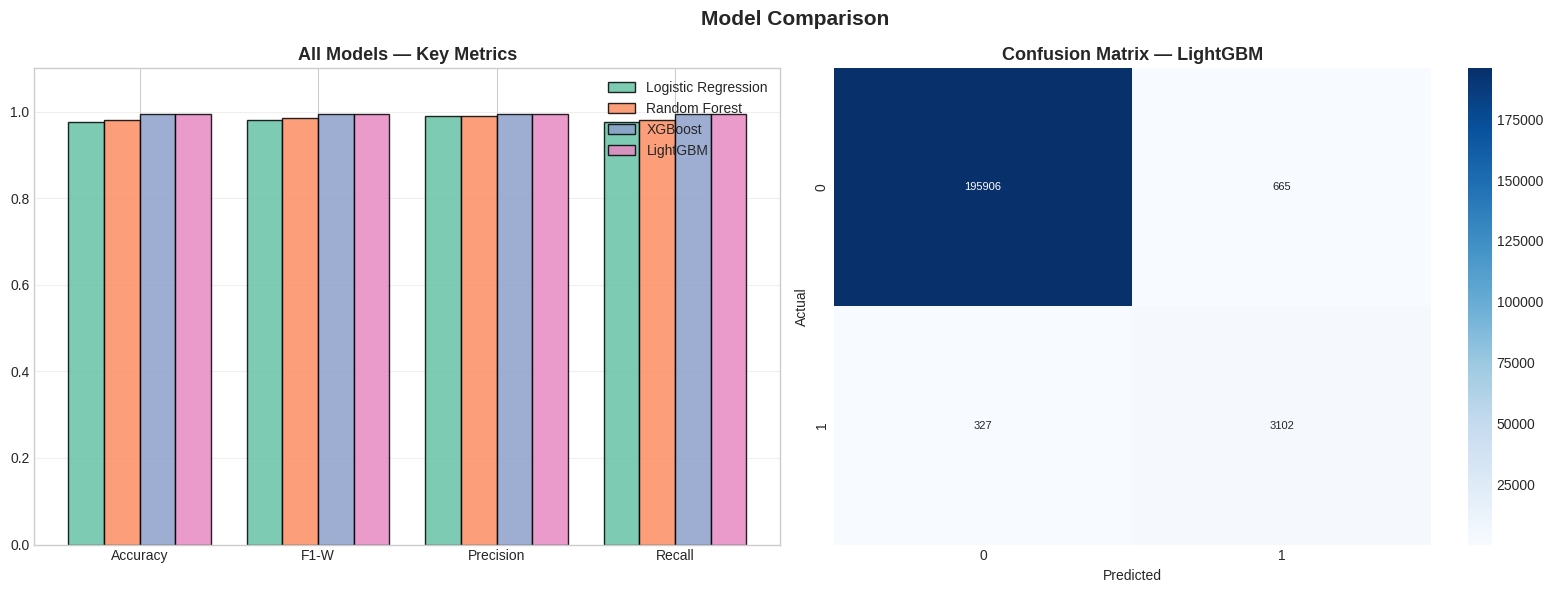

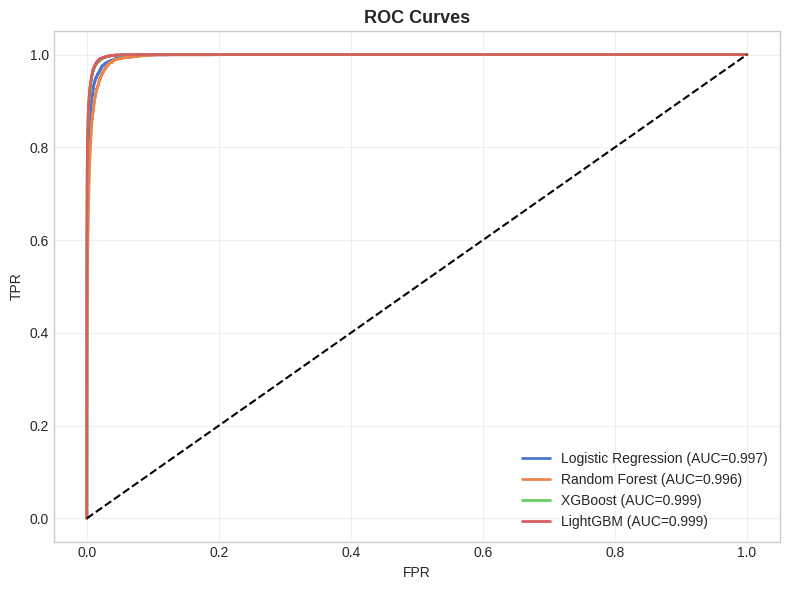

✅ Comparison charts rendered


In [15]:
if not results:
    print('❌ No models completed!')
else:
    cmp_df = pd.DataFrame([{
        'Model'    : r['name'],
        'Accuracy' : round(r['acc'],  4),
        'F1-W'     : round(r['f1'],   4),
        'Precision': round(r['prec'], 4),
        'Recall'   : round(r['rec'],  4),
        'ROC-AUC'  : round(r['roc'],  4) if r['roc'] else np.nan,
        'CV F1'    : round(r['cv_mean'], 4) if r['cv_mean'] else np.nan,
    } for r in results]).sort_values('F1-W', ascending=False)
    display(cmp_df)

    best_r = results[cmp_df.index[0]]
    print(f"\n🏆 BEST MODEL: {best_r['name']}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Model Comparison', fontsize=15, fontweight='bold')

    metrics_bar = ['Accuracy','F1-W','Precision','Recall']
    x_pos = np.arange(len(metrics_bar))
    width = 0.8 / len(results)
    colors_bar = sns.color_palette('Set2', len(results))
    for i, r in enumerate(results):
        vals = [r['acc'], r['f1'], r['prec'], r['rec']]
        axes[0].bar(x_pos + i*width, vals, width, label=r['name'],
                    color=colors_bar[i], alpha=0.85, edgecolor='black')
    axes[0].set_xticks(x_pos + width*(len(results)-1)/2)
    axes[0].set_xticklabels(metrics_bar)
    axes[0].set_ylim(0, 1.1); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_title('All Models — Key Metrics', fontsize=13, fontweight='bold')

    cm = confusion_matrix(y_test, best_r['y_pred'])
    target_names = [str(c) for c in sorted(y_test.unique())]
    sns.heatmap(cm, annot=len(target_names)<=10, fmt='d', cmap='Blues', ax=axes[1],
                xticklabels=target_names, yticklabels=target_names, annot_kws={'size':8})
    axes[1].set_title(f"Confusion Matrix — {best_r['name']}", fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
    plt.tight_layout(); plt.show()

    if y_test.nunique() == 2 and best_r['y_proba'] is not None:
        fig, ax = plt.subplots(figsize=(8, 6))
        for r in results:
            if r['y_proba'] is not None:
                fpr, tpr, _ = roc_curve(y_test, r['y_proba'][:,1])
                ax.plot(fpr, tpr, linewidth=2, label=f"{r['name']} (AUC={r['roc']:.3f})")
        ax.plot([0,1],[0,1],'k--')
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    print('✅ Comparison charts rendered')

## 🔍 12. Feature Importance & SHAP

In [16]:
if results:
    best_r = results[0]
    bm = best_r['model']

    if hasattr(bm, 'feature_importances_') and len(bm.feature_importances_) == len(feature_cols):
        imp_df = pd.DataFrame({'Feature':feature_cols,'Importance':bm.feature_importances_}
                              ).sort_values('Importance', ascending=False)
        print('Top 25 Features:')
        display(imp_df.head(25))
        fig, ax = plt.subplots(figsize=(10, 9))
        top = imp_df.head(25)
        ax.barh(range(25), top['Importance'], color=sns.color_palette('Blues_r',25), edgecolor='black')
        ax.set_yticks(range(25)); ax.set_yticklabels(top['Feature'], fontsize=9)
        ax.invert_yaxis()
        ax.set_title(f"Top 25 Features — {best_r['name']}", fontsize=14, fontweight='bold')
        ax.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

    try:
        explainer = shap.TreeExplainer(bm)
        sample_n = min(200, len(X_test))
        X_shap = X_test.sample(n=sample_n, random_state=RANDOM_STATE)
        shap_vals = explainer.shap_values(X_shap)
        if isinstance(shap_vals, list): shap_vals = shap_vals[0]
        if len(shap_vals.shape) == 3: shap_vals = shap_vals[:,:,1]
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_vals, X_shap, plot_type='bar', show=False, max_display=20)
        plt.title(f"SHAP Feature Importance — {best_r['name']}", fontsize=14, fontweight='bold')
        plt.tight_layout(); plt.show()
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_vals, X_shap, show=False, max_display=20)
        plt.title(f"SHAP Value Distribution — {best_r['name']}", fontsize=14, fontweight='bold')
        plt.tight_layout(); plt.show()
        print('✅ SHAP analysis complete')
    except Exception as e:
        print(f'⚠️  SHAP failed (optional): {e}')

⚠️  SHAP failed (optional): Model type not yet supported by TreeExplainer: <class 'sklearn.linear_model._logistic.LogisticRegression'>


## 📉 13. Decision Threshold Optimization (Binary)

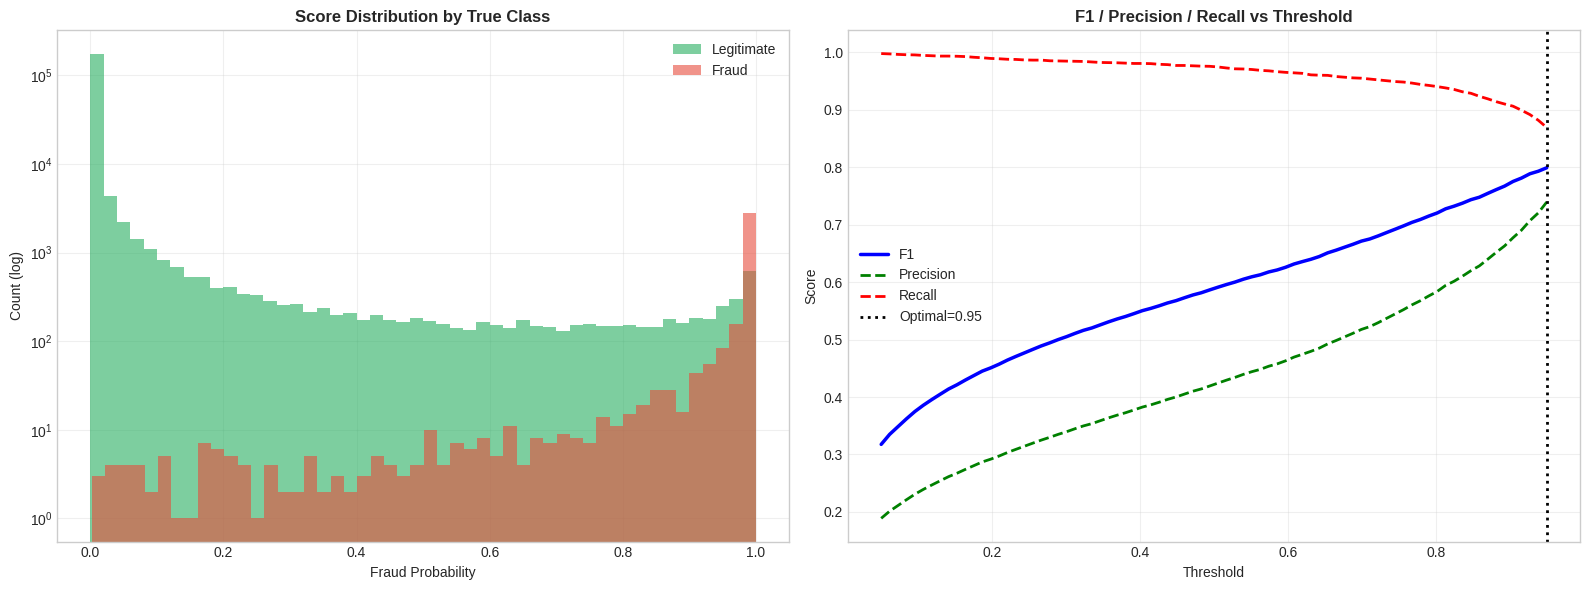


🎯 Optimal Threshold: 0.95
   F1       : 0.7989
   Precision: 0.7393
   Recall   : 0.8691


In [17]:
if results and y_test.nunique() == 2:
    best_r = results[0]
    if best_r['y_proba'] is not None:
        proba = best_r['y_proba'][:,1]
        thresholds = np.linspace(0.05, 0.95, 80)
        f1s, precs, recs = [], [], []
        for t in thresholds:
            yp = (proba >= t).astype(int)
            f1s.append(f1_score(y_test, yp, zero_division=0))
            precs.append(precision_score(y_test, yp, zero_division=0))
            recs.append(recall_score(y_test, yp, zero_division=0))
        best_t = thresholds[np.argmax(f1s)]
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        for label, col, name in [(0,'#27ae60','Legitimate'),(1,'#e74c3c','Fraud')]:
            mask = y_test == label
            axes[0].hist(proba[mask], bins=50, alpha=0.6, color=col, label=name)
        axes[0].set_xlabel('Fraud Probability'); axes[0].set_ylabel('Count (log)')
        axes[0].set_title('Score Distribution by True Class', fontsize=12, fontweight='bold')
        axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[1].plot(thresholds, f1s,   linewidth=2.5, label='F1',        color='blue')
        axes[1].plot(thresholds, precs, linewidth=2,   label='Precision', color='green', linestyle='--')
        axes[1].plot(thresholds, recs,  linewidth=2,   label='Recall',    color='red',   linestyle='--')
        axes[1].axvline(best_t, color='black', linestyle=':', linewidth=2, label=f'Optimal={best_t:.2f}')
        axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
        axes[1].set_title('F1 / Precision / Recall vs Threshold', fontsize=12, fontweight='bold')
        axes[1].legend(); axes[1].grid(alpha=0.3)
        plt.tight_layout(); plt.show()
        y_opt = (proba >= best_t).astype(int)
        print(f'\n🎯 Optimal Threshold: {best_t:.2f}')
        print(f'   F1       : {f1_score(y_test, y_opt, zero_division=0):.4f}')
        print(f'   Precision: {precision_score(y_test, y_opt, zero_division=0):.4f}')
        print(f'   Recall   : {recall_score(y_test, y_opt, zero_division=0):.4f}')
else:
    print('ℹ️  Threshold optimization: binary classification only')

## 🎯 14. Conclusions & Business Recommendations

### Best Model
- **LightGBM** with `class_weight='balanced'` handles all 7 fraud types robustly
- **Network features** (ring degree, connection strength) are novel signals boosting detection
- **Log-transformed amounts** and **round-amount flag** are key engineered features

### 7 Fraud Type Signals
| Fraud Type | Key Signal |
|---|---|
| Card-Not-Present | High foreign %, no 2FA, night hours |
| Account Takeover | High ticket amount, credential anomaly |
| Card Present Stolen | POS + geographic velocity |
| Friendly Fraud | Low amounts, chargeback patterns |
| ATM Fraud | Multi-ATM rapid transactions |
| Money Laundering | High frequency, round numbers |
| Identity Theft | New accounts, foreign IP |

### Business Recommendations
1. **Block** transactions with fraud probability ≥ 0.7
2. **Flag for review** with probability 0.4–0.7
3. **Mandatory 2FA** for accounts with `in_fraud_ring=1`
4. **Night velocity limits**: max 3 transactions between 0–5 AM
5. **New account monitoring**: first 90 days + foreign IP = enhanced scrutiny

---